# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 12. Решение дифференциальных уравнений с помощью нейронных сетей. PINN, DeepONet, FNO`

## `Занятие провел: Иванов Егор (@e1vanov)`
## `Материал составил: Иванов Егор (@e1vanov)`

### `Москва, Весенний семестр 2026`

Источники:

- Статья 1 по **PINN**. Решение ДУ: [Maziar Raissi et al., 2017](https://arxiv.org/abs/1711.10561), примерно 2200 цитирований
- Статья 2 по **PINN**. Обратные задачи: [Maziar Raissi et al., 2017](https://arxiv.org/abs/1711.10566), примерно 2200 цитирований
- **DeepONet**: [Lu Lu et al., 2019](https://arxiv.org/abs/1910.03193), примерно 1200 цитирований
- Neural Operator (**FNO, LNO, ...**): [Nikola Kovachki et al., 2021](https://arxiv.org/abs/2108.08481), примерно 2000 цитирований

- Теорема об универсальной аппроксимации операторов. [Chen, Chen, 1995](https://www.researchgate.net/profile/Tianping-Chen/publication/3302007_Universal_approximation_to_nonlinear_operators_by_neural_networks_with_arbitrary_activation_functions_and_its_applications_to_dynamic_systems/links/5580152308aeea18b77a8dd0/Universal-approximation-to-nonlinear-operators-by-neural-networks-with-arbitrary-activation-functions-and-its-applications-to-dynamic-systems.pdf), примерно 1800 цитирований

- Обучение операторов. Обзор: [Nicolas Boullé, Alex Townsend, 2023](https://arxiv.org/abs/2312.14688), примерно 140 цитирований

Обсудим, как можно научить нейронную сеть физике и как с помощью этого можно построить альтернативу классическим численным солверам ОДУ и обратных задач.
Кроме того, на прошлых лекциях вы узнали, что нейронные сети являются универсальными аппроксиматорами функций. В этот раз мы повысим ставки и поговорим о том, могут ли нейронные сети аппроксимировать отображения между бесконечномерными пространствами - операторы, например, отображающие функции, задающие ДУ, в его решение.

---

## Мотивация

Рассмотрим задачу бинарной классификации изображений кошек и собак.

#### <font color="orange">**Вопрос (на повторение):**</font> Как можно ее решать?

#### Ответ:

Составим решающее правило как композицию нейронных сетей следующего вида:

- **Извлечение признаков**: сверточная нейронная сеть (CNN)
- **Обработка признаков**:
полносвязная сеть (MLP)
- **Функция потерь**:
бинарная кросс-энтропия (BCE)

#### **<font color="orange">Вопрос.</font>** Используется ли в предложенном решении тот факт, что в датасете именно кошки и собаки? Изменится ли подход, если это будут автомобили и самолеты?

#### Ответ:

Нет, не изменится.

Для многих прикладных задач априорные знания плохо поддаются математической формализации, и мы надеемся, что сеть в процессе оптимизации *"сама разберется"*. Из-за этого (или благодаря этому) естественный отбор при эволюции методов прошли **самые универсальные** слои, архитектуры, методы оптимизации и т.д.

### Ключевая идея

Что, если применить универсальные подходы для задач с математически формализованным априорным знанием, каковыми являются **физические** задачи?

Возьмем **лучшее** от обоих подходов:
- от нейронных сетей &ndash; универсальность,
- от физической постановки &ndash; априорные знания.

## Постановки задач

**Опр.** **Sci**entific **ML** (SciML) &ndash;
 область глубокого обучения, изучающая применение нейросетей для решения физических задач.

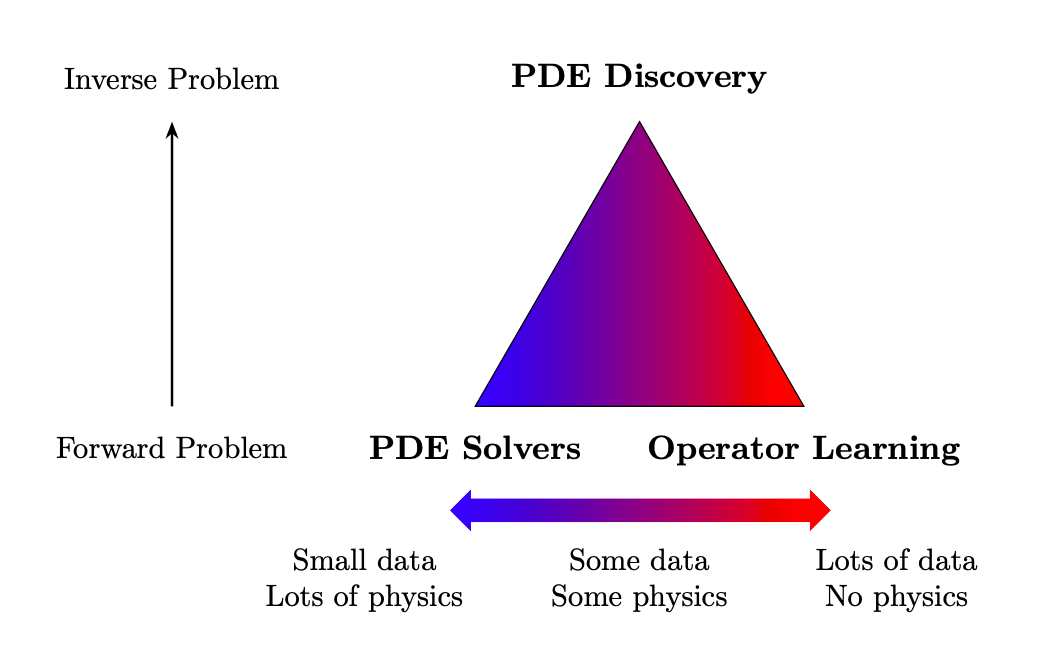

[Источник](https://arxiv.org/abs/2312.14688)

Существует несколько вариантов постановки задачи, они отличаются между собой соотношением количества известной "физики" и данных:

- **Решение уравнений (УЧП, ОДУ)**. Предположим, вам известны законы, которым подчиняется некоторая физическая система (пусть, например, они выражены в форме дифференциальных уравнений). Кроме того, имеется некоторое (обычно небольшое) количество измерений этой системы. Цель: построить модель этой физической системы.

- **Обратные задачи (восстановление параметров)**. У нас есть некоторое количество измерений, но физика процесса известна не полностью. Цель: восполнить этот недостаток на основе данных.

- **Operator Learning**. Физическая задача порождает оператор, действующий между бесконечномерными пространствами. Цель: обучить нейронную сеть, аппроксимирующую этот оператор. В качестве примера, имеющего прикладную ценность, можно привести оператор, ставящий в соответствие функциям, задающим ДУ, его решение.



## Physics-Informed Neural Networks (PINNs)

Первой успешной попыткой применения нейронных сетей для решения физических задач стали Physics-Informed Neural Networks (PINNs).

Рассмотрим следующую постановку задачи.

Имеется одномерный $x\in(0,1)$ стержень, который остывает в течение интервала времени $t\in(0,1)$ при некотором изначальном распределении температуры $\varphi(x)$. Обозначим за $u(t,x)$ температуру стержня в момент времени $t$ в координате $x$.

В нашем распоряжении имеется набор измерений температуры стержня с датчиков &ndash; обучающая выборка:

$$
\left\{
(x_n, t_n), u_n
\right\},
n\in1,\dots,N
$$

Требуется определить температуру стержня в других точках &ndash; на тестовой выборке.

Предложим **наивное** решение с использованием нейронных сетей.

Действительно, искомая функция $u$ это отображение $\mathbb R^2\to\mathbb R^1$, которое можно параметризовать нейронной сетью $f_\theta(t,x)$, например, полносвязной. Для определения параметров модели будем минимизировать MSE с данными наблюдений:

$$
\theta^*=
\text{argmin}
\frac{1}{N}
\sum_{n=1}^N
|u_n-f_\theta(t_n,x_n)|^2
$$

<font color="orange">**Вопрос:**</font> Какие проблемы могут возникнуть при решении поставленной задачи таким способом?

#### Ответ:


 Предложенный подход будет подвержен *переобучению*. Действительно, если данных наблюдений не слишком много и/или в них присутствует шум, то обучение нейронной сети с легкостью может обеспечить нулевые потери на тренировочной выборке с **нефизичным** решением вне нее.

#### Physics-informed Loss

Будем бороться с переобучением с помощью регуляризатора, основанного на физике задачи. Действительно, функций, интерполирующих данные наблюдений, много, поэтому разумно наложить дополнительные ограничения. Выпишем уравнение теплопроводности, которому подчиняется распределение температуры в стержне.

$$
\left\{
\begin{aligned}
    &u_t - \lambda u_{xx} = 0\\
    &u(t, 0) = u(t, 1) = 0\\
    &u(0, x) = \varphi(x)
\end{aligned}
\right.
$$

- В случае, если $\lambda$ известен, мы находимся в постановке решения УЧП &ndash; обучаем функцию, которая описывает наблюдения и соответствует физическому закону во всей области.

- Если же $\lambda$ не известен, то задача становится обратной: мы доуточняем физику на основе данных, добавляя к оптимизируемым переменным неизвестные физические постоянные.

Под соответствием физике мы понимаем то, что функция является решением задачи, то есть удовлетворяет дифференциальному уравнению, граничным и начальным условиям. Самый простой способ это сделать &ndash; **внести эти требования в функцию потерь.**

$$
\mathsf L_{\mathrm{total}}=
\mathsf L_{\mathrm{data}}+
\alpha_1\mathsf L_{\mathrm{de}}+
\alpha_2\mathsf L_{\mathrm{boundary}}+
\alpha_3\mathsf L_{\mathrm{initial}},
$$
где, например,
$$
\mathsf L_{\mathrm{de}} = \frac{1}{M}
\sum_{i=1}^{M}
\left|\partial_t\mathrm{NN}(t_i',x_i')
-\lambda\:\partial_{xx}\mathrm{NN}(t_i',x_i')
\right|^2
$$

<font color="orange">**Вопрос:**</font> Почему на такую функцию потерь можно обучать нейронную сеть?

#### Ответ:

Функция, задаваемая нейронной сетью дифференцируема как по параметрам, так и по входам, причём производные по входам &ndash; это так же некоторые дифференцируемые функции от параметров.

Единственное, что может смутить &ndash; потребление памяти. Подсчет третьих (или даже более высокого порядка) производных может показаться жутким, что действительно так в случае гигантских сеток, но в физических задачах размерности низкие, а сами сетки &ndash; редко сложнее сверточных.

<font color="orange">**Вопрос:**</font> В каких точках считать регуляризатор в функции потерь?

#### Ответ:

Версия №0: в тех же, в которых известны данные наблюдений, хотя на самом деле верно более смелое предположение &ndash; **в любых**.

Действительно, эти точки авторы PINN'ов предложили называть *виртуальными*, что точно отражает суть их использования.

Будем использовать составную
функцию потерь:

$$
\mathsf L_{\mathrm{total}}=
\mathsf L_{\mathrm{data}}+
\alpha_1\mathsf L_{\mathrm{virtual}}^{\mathrm{de}}+
\alpha_2\mathsf L_{\mathrm{virtual}}^{\mathrm{boundary}}+
\alpha_3\mathsf L_{\mathrm{virtual}}^{\mathrm{initial}},
$$
где, например,
$$
\mathsf L_{\mathrm{virtual}}^{\mathrm{de}} = \frac{1}{N_{\mathrm{virtual}}}
\sum_{i=1}^{N_{\mathrm{virtual}}}
\left|\partial_t\mathrm{NN}(t_i,x_i)
-\lambda\:\partial_{xx}\mathrm{NN}(t_i,x_i)
\right|^2
$$

Виртуальные точки являются очень полезной степенью свободы. Например, их можно выбирать новыми для каждого батча / эпохи разными способами &ndash; случайной инициализацией или основываясь на априорных знаниях о виде функции.

#### Пример из статьи. Решение ДУ

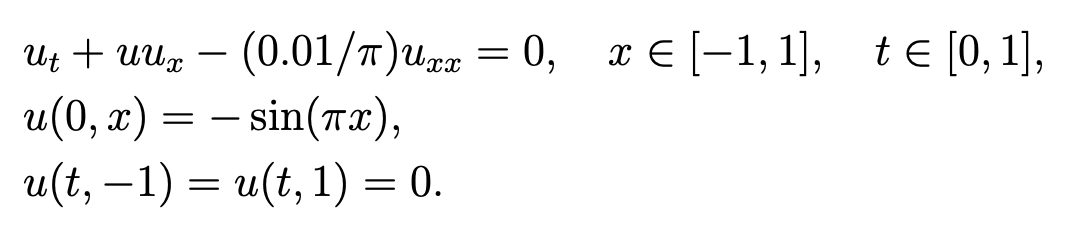
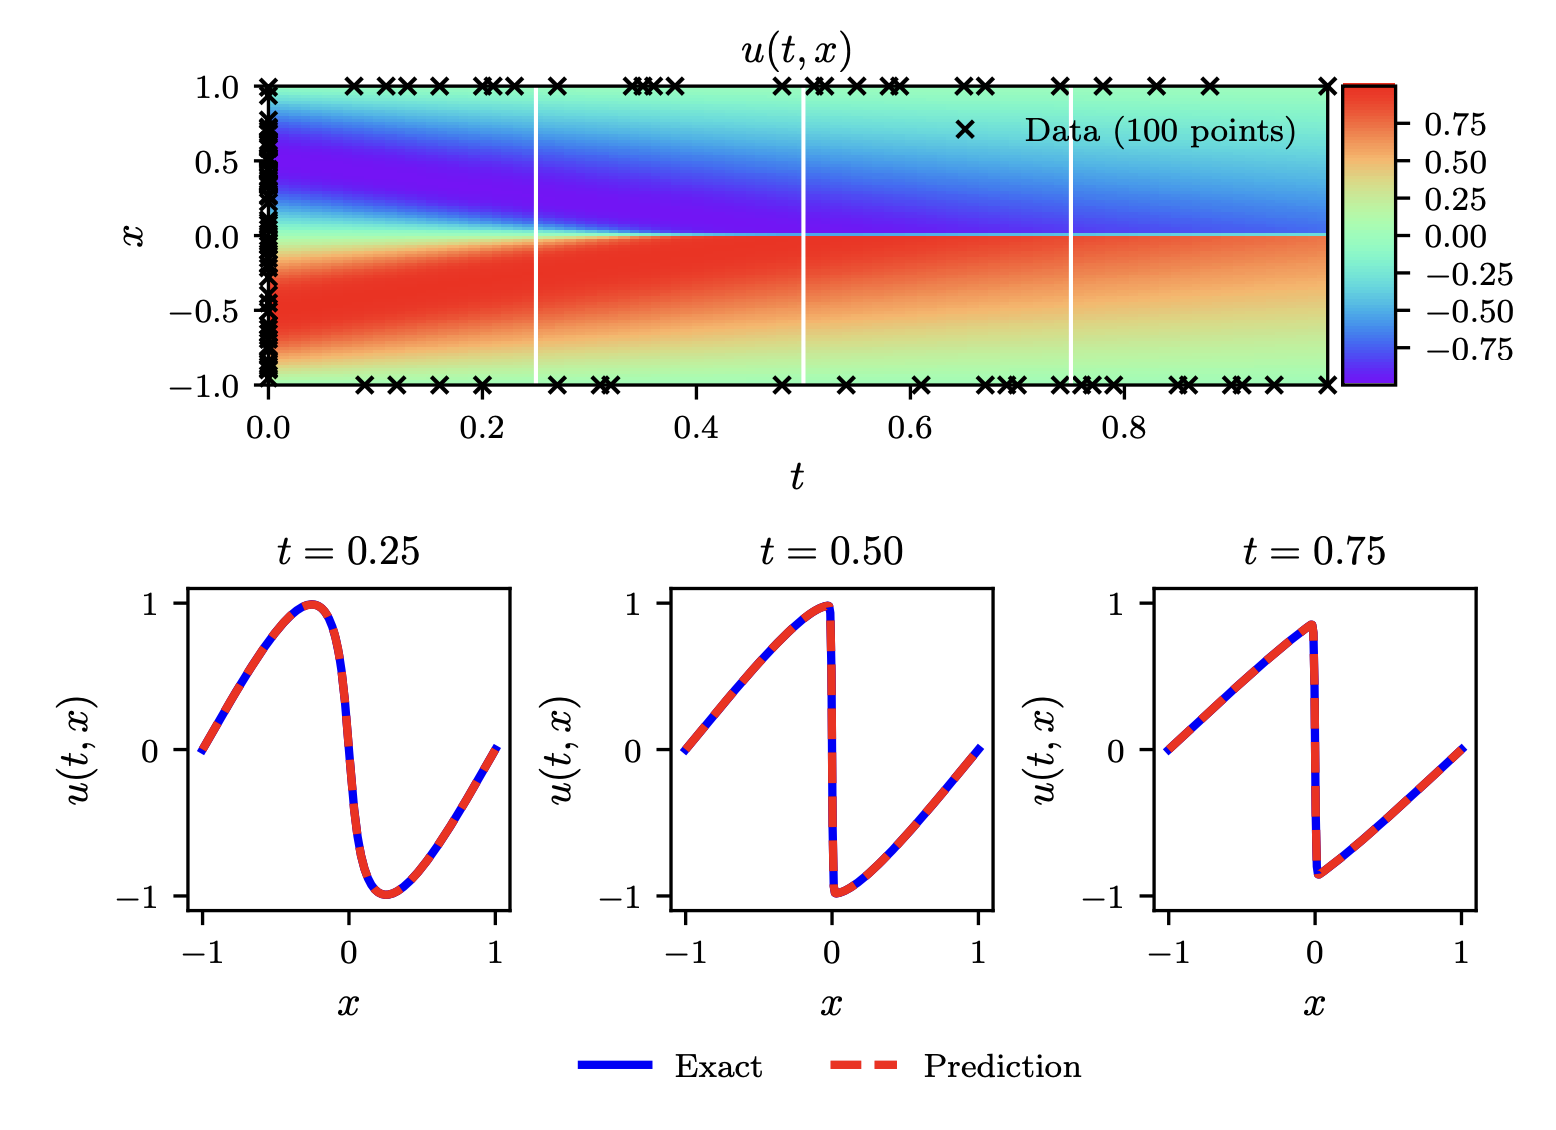

[Источник](https://arxiv.org/abs/1711.10561)

#### Пример из статьи. Обратная задача

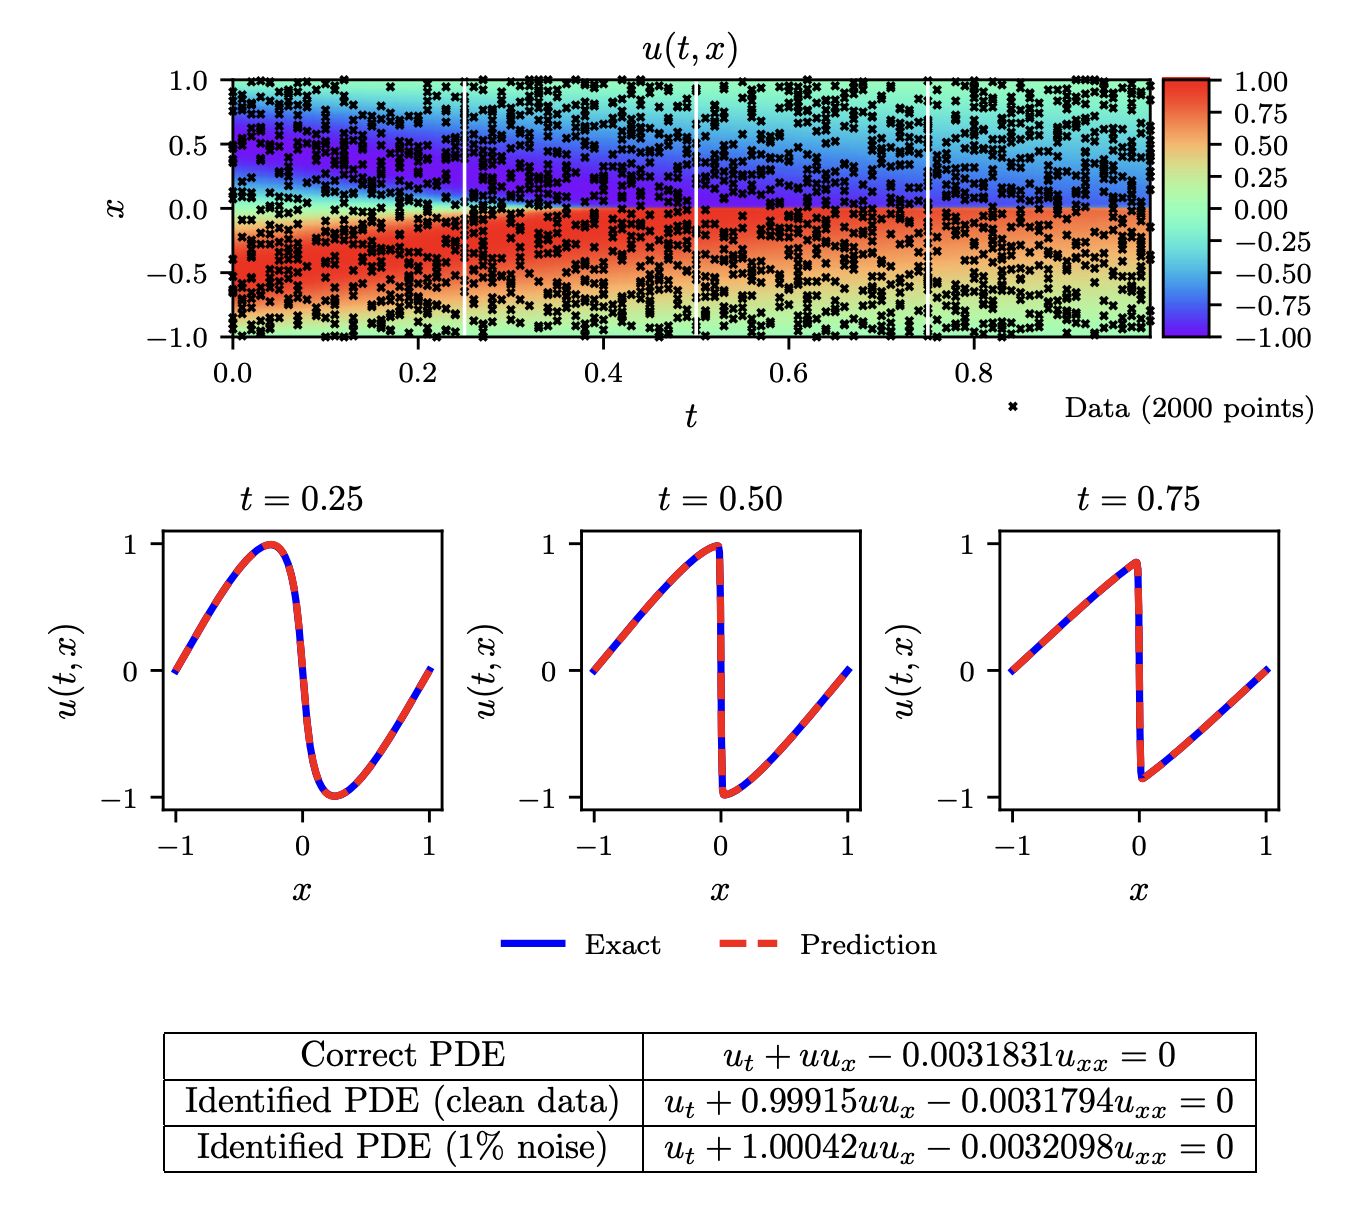

[Источник](https://arxiv.org/abs/1711.10566)

## Operator Learning (DeepONet, FNO)

Повысим сложность: можно ли "выучить" целую задачу (оператор), а не конкретное ДУ.

Напомним постановку задачи классического обучения с учителем: имеется набор прецедентов $\left\{(x_i, y_i)\right\}$ действия некоторого отображения $f:\mathsf X\to\mathsf Y$. Требуется восстановить это отображение на основе данных наблюдений.

До этого пространства $\mathsf X$ и $\mathsf Y$ были конечномерными. Что, если попробовать обобщить эту постановку на бесконечномерный случай? Иными словами, пример действия отображения (оператора) теперь &ndash; пара функций $(u,v)$. Рассмотрим следующие примеры.

- **Пример 1.** УЧП
$$
\begin{aligned}
    -\nabla\cdot(a(\textbf x)\nabla u(\textbf x)) = f(\textbf x)&,\: \textbf x\in D\\
    u(\textbf x)=0&,\:\textbf x\in\partial D
\end{aligned}
$$
Функции $a$ и $f$ подаются на вход нейронной сети,
выходом которой является функция $u$ &ndash; решение УЧП.
        
- **Пример 2.** Динамическая система
$$
\begin{aligned}
    \frac{dx}{dt} = u(t),\: t\in[0,1]&\\
    x(0)=x_0&
\end{aligned}
$$
Функция $u$ подается на вход нейронной сети,
выходом является функция $x$.

<font color="orange">**Вопрос:**</font> Что вы можете предложить в качестве решения?

#### Ответ:

В качестве идеи №0 можно отождествить функцию с ее конечной дискретизацией и обучать нейронную сеть отображать сетку значений входа в сетку значений выхода.

Предложенное решение безусловно рабочее при определенных условиях, например, в случае, если известно, что дискретизация не будет меняться. Однако перед нами стоит цель аппроксимировать именно оператор.

Кроме того, под тем, что нейронная сеть оперирует над функциями, мы понимаем, что для этих функций возможно вычисление значения в произвольной точке. Можно возразить, что это не проблема, поскольку эти значения можно, например, интерполировать. Это действительно так.

Более сложным и интересным свойством, которое мы ожидаем от нейронного оператора, является "независимость" от дискретизации. Под независимостью мы понимаем то, что нейронная сеть способна обрабатывать функции на произвольной дискретизации и, более того, уточнять свое предсказание при ее измельчении.

### DeepONet

#### Теорема об универсальном аппроксиматоре

**Теорема (Цыбенко; 1989).**

Пусть $\phi(\xi)=1/(1+\exp\{-\xi\})$ - сигмоидная функция.
Тогда для любой непрерывной функции $f:X\to\mathbb R$, где
$X$ - компакт в $\mathbb R^n$ и $\varepsilon>0$
существуют векторы $\textbf{w}_1,\dots,\textbf{w}_N,
\boldsymbol{\alpha}, \boldsymbol{\theta}$ такие, что
неравенство
$$
\big|
f(\textbf x) -
\sum_{i=1}^N\alpha_i \phi(\langle \textbf x,
\textbf w_i\rangle + \theta_i)
\big|
< \varepsilon
$$
справедливо всюду в $X$.

Иными словами, для наперед заданных функции и погрешности
существует *достаточно широкая*
полносвязная нейронная сеть с 2 слоями, обеспечивающая нужную
точность.

<font color="orange">**Вопрос (на повторение):**</font> Данная теорема является не более чем *оправданием* использования полносвязных сетей для решения задач глубокого обучения. Почему?

#### Ответ:

Действительно, теорема утверждает, что класс полносвязных сетей может с любой точностью приблизить любую непрерывную функцию. Ответа на вопрос, как такой аппроксиматор искать и сойдётся ли метод оптимизации к нему по обучающей выборке, теорема не дает.

#### Теорема об универсальном аппроксиматоре. Операторный случай


Оказывается, что схожий результат есть и в операторном случае:

**Теорема (Chen, Chen; 1995).**

Пусть $\sigma$ - непрерывная
неполиномиальная функция, $X$ &ndash;
банахово пространство, $K_1$ &ndash; компакт в $X$,
$K_2$ &ndash; компакт в $\mathbb R^d$, $V$ &ndash; компакт в $C(K_1)$,
$G: V\to C(K_2)$ &ndash; нелинейный непрерывный оператор.
Тогда для любого числа $\varepsilon$
существуют числа $n, p, m$, константы
$c_i^k, \xi_{ij}^k, \theta_{i}^k, \zeta_k\in R$ и
векторы $\textbf w_k\in \mathbb R^d$, $\textbf x_j\in K_1$,
$i=1,\dots,n,\:k=1,\dots, p,\:j=1,\dots, m$ такие, что
неравество
$$
\big|
G(u)(\textbf y) -
\sum_{k=1}^p
\sum_{i=1}^n
c_i^k
\sigma\left(
\sum_{j=1}^m\xi_{ij}^k u(\textbf x_j) + \theta_i^k
\right)
\sigma(\langle \textbf w_k, \textbf y\rangle + \zeta_k)
\big|<\varepsilon
$$
справедливо для любых $u\in V$ и $\textbf y\in K_2$.

**Удивительный факт.** [Статья, в которой была доказана эта теорема](https://www.researchgate.net/profile/Tianping-Chen/publication/3302007_Universal_approximation_to_nonlinear_operators_by_neural_networks_with_arbitrary_activation_functions_and_its_applications_to_dynamic_systems/links/5580152308aeea18b77a8dd0/Universal-approximation-to-nonlinear-operators-by-neural-networks-with-arbitrary-activation-functions-and-its-applications-to-dynamic-systems.pdf), завершается рассуждениями авторов о том, что такой вид может позволить обучать нейронные сети для аппроксимации операторов. Реализация этой идеи случилась лишь спустя 25 лет в [статье по DeepONet](https://arxiv.org/abs/1910.03193).

Если победить страх большого количества обозначений, можно обратить внимание на то, что универсальный аппроксиматор, предложенный в теореме выше, представляет собой скалярное произведение двух полносвязных сетей:
- **Branch Net:** сеть, принимающая
на вход значения функции в фиксированном наборе точек
$\{\textbf x_j\}$
- **Trunk net:** сеть, принимающая на вход
точку $\textbf y$, в которой
нужно вычислить результат действия оператора.

Кроме того, можно увидеть и идею, связанную с разделением переменных:
$$
G(u)(\textbf y)
\approx
\hat G(u(\textbf x_1), \dots, u(\textbf x_m), \textbf y)=
\left\langle
\mathrm{branch}(u(\textbf x_1),\dots,u(\textbf x_m)),
\mathrm{trunk}(\textbf y)
\right\rangle
$$
Задача аппроксимации результата действия оператора (функции) в точке разбивается на две: извлечение информации о самой функции и об интересующей точке.

На основе утверждения теоремы авторы статьи предложили следующие архитектуры:

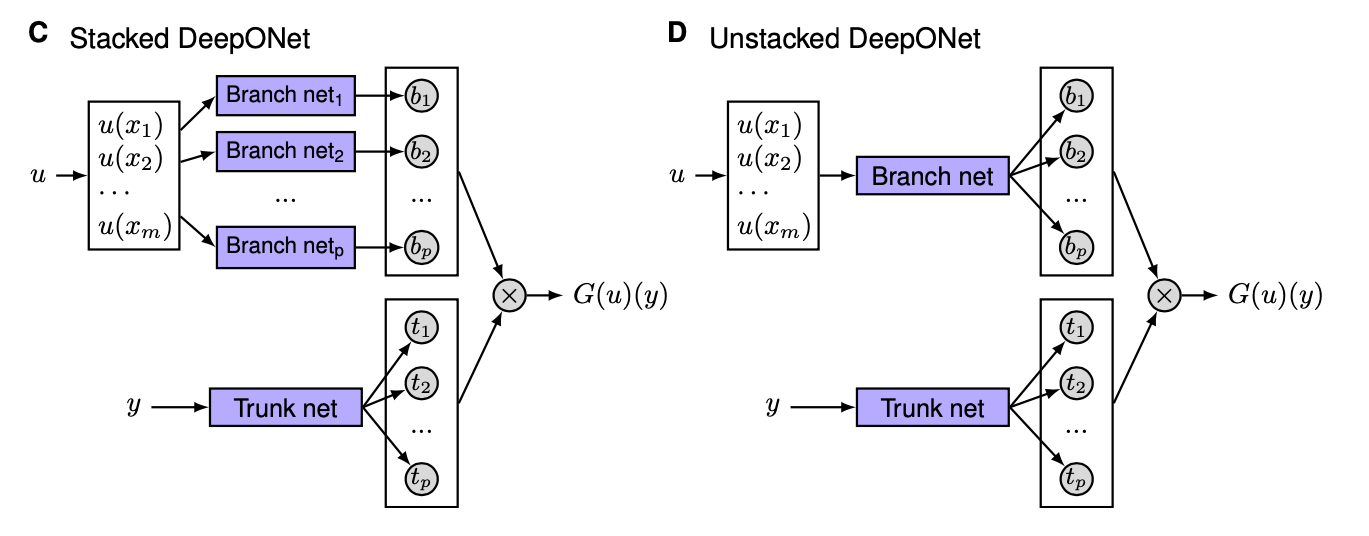

[Источник](https://arxiv.org/abs/1910.03193)

#### `Пример из статьи. Уменьшение переобучения`

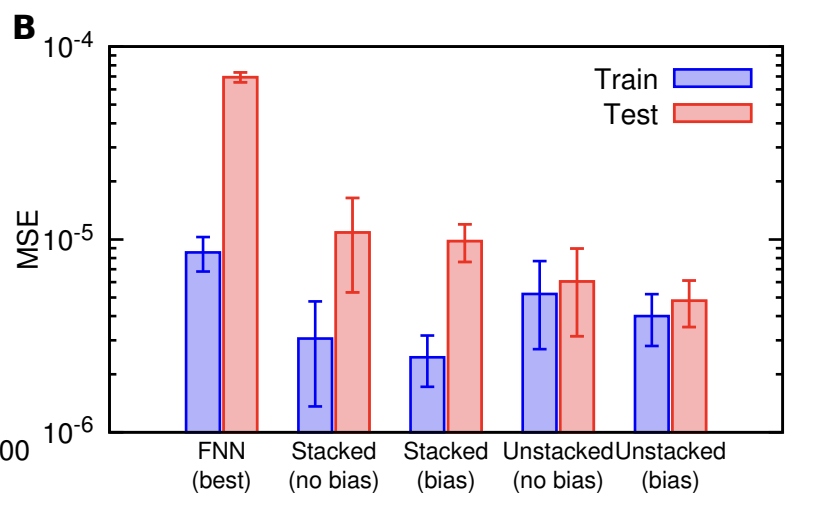

[Источник](https://arxiv.org/abs/1910.03193)

<font color="orange">**Вопрос:**</font> Удовлетворяет ли DeepONet тем свойствам, которые мы требуем от нейронного оператора?

#### Ответ:

Результат действия оператора может быть вычислен в произвольной точке (без использования интерполяции) &ndash; она подается на вход. Набор узлов фиксирован, поэтому изменить (и тем более измельчить) дискретизацию входа нельзя.

### Neural Operators. FNO

#### Мотивация

Напомним функциональный вид полносвязных сетей:

$$
\mathrm{NN}(\textbf x) =
\sigma
\left(
\textbf A_L(\cdots\sigma(\textbf A_1\textbf x+\textbf b_1)\cdots)
+
\textbf b_L
\right)
$$

Аппроксиматор строится
как поочередная композиция линейных и нелинейных отображений. Используя упомянутые выше теоремы, а
также прикладной опыт использования
полносвязных и сверточных нейронных сетей,
можно предложить их обобщение
на бесконечномерный случай.

- В качестве *линейного* отображения предлагается
использовать интеграл с обучаемым ядром. Это отображение инвариантно относительно
дискретизации и сходится к истинному значению интеграла
при ее измельчении.

$$
\mathsf K_i(u_i)(\textbf x)=
\int_{\Omega_i} K_i(\textbf x,\textbf y)u_i(\textbf y)d\textbf y
$$

- В качестве *смещения* так же предлагается использовать функцию:

$$
\mathsf B_i(u_i)(\textbf x) = u_i(\textbf x) + b_i(\textbf x)
$$

- В качестве *нелинейных* отображений (активаций)
предлагается использовать
нелинейные функции $\sigma$, применяемые поточечно.
Например, часто используемые в глубоком
обучении ReLU, $\tanh$ и т.д.

#### Теорема об универсальном аппроксиматоре


**Теорема (2022).** Пусть $\mathsf A$, $\mathsf U$ &ndash; банаховы пространства
функций, $\mathsf G^\dagger:\mathsf A\to\mathsf U$ &ndash;
нелинейный оператор.
При определенных предположениях на все упомянутые выше объекты,
если положить ядра и смещения полносвязными нейронными сетями,
для любого компакта $K\subset \mathsf A$ и $0<\varepsilon\le1$
существует $N\in\mathbb N$ и
нейронный оператор $\mathrm{NO}_N$ такой, что
$$
\sup_{a\in K}
\|
\mathrm{NO}_N(a) - \mathsf G^\dagger(a)
\|_\mathsf U \le \varepsilon
$$

#### Архитектура нейронных операторов


Архитектуры нейронных операторов
отличаются друг от друга способом
параметризации и вычисления интегральных операторов.

Наиболее известный подход &ndash; *Fourier Neural Operator (FNO)*,
основанный на использовании операции свертки, т.е.
$$
\mathsf K_i(u_i)(\textbf x)=
\int_{\Omega_i} K_i(\textbf x,\textbf y)u_i(\textbf y)d\textbf y=
\int_{\Omega_i} K_i(\textbf x - \textbf y)u_i(\textbf y)d\textbf y=
\mathsf F^{-1}
\mathsf F(K_i)\mathsf F(u_i)
$$

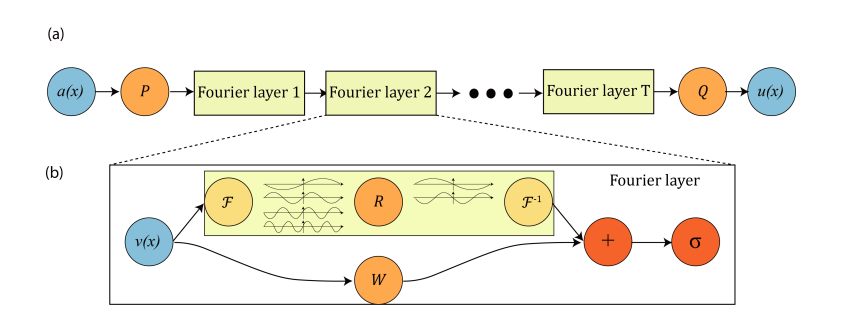

[Источник](https://arxiv.org/abs/2108.08481)

Пройдем по слоям и выпишем размерности возникающих тензоров:

- Дискретизация функций на входе: (T)
- Поточечный подъем размерности: (T, H)
- Преобразование Фурье вдоль временной оси: (F, H)
- Обрезаем высокие частоты: (Fr, H)
- Для каждой частоты применяем линейное преобразование: (Fr, H)
- Дополняем нулями старшие гармоники: (F, H)
- Делаем обратное преобразование Фурье: (T, H)
- Поточечное понижение размерности: (T)

<font color="orange">**Вопрос:**</font> Удовлетворяет ли FNO тем свойствам, которые мы требуем от нейронного оператора?

#### Ответ:

Да, но с оговорками. Вычисление в произвольной точке осуществляется за счет интерполяции. Дискретизация произвольная, но регулярная для того, чтобы применять Фурье.

#### Пример из статьи

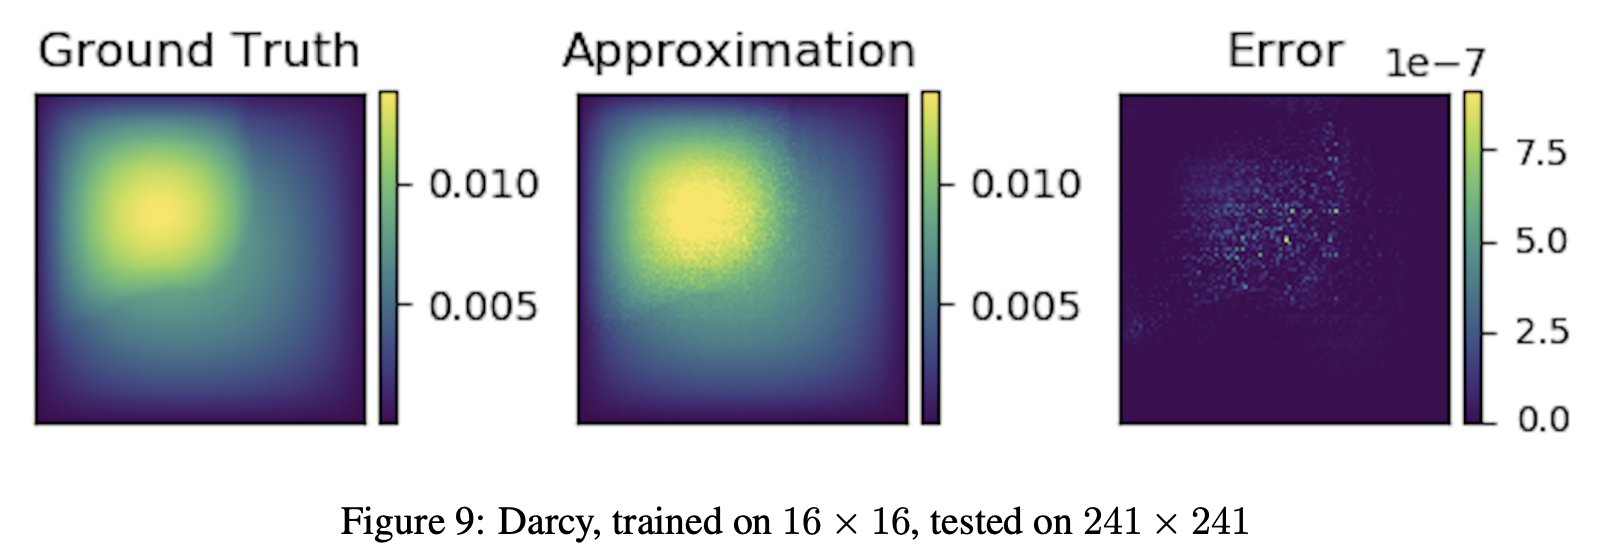

[Источник](https://arxiv.org/abs/2108.08481)

#### Приложения нейронных операторов


Несмотря на то, что инвариантность относительно дискретизации кажется свойством, которое представляет исключительно теоретический интерес, оно находит ряд приложений. Например, (пред)обработка изображений произвольного разрешения, последовательностей произвольной длины, графов и так далее.